In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.patches as mpatches

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from scipy import stats

In [2]:
OUTPUT_DIR = r"C:\Courses\Innopolis\2026\ВЭД\Данные2"

In [5]:
df_po = pd.read_csv(f"{OUTPUT_DIR}\\fact_purchase_orders_clean.csv")

df_suppliers = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_suppliers.csv")
    .loc[:, ["supplier_id", "country_id", "years_of_relationship", "maturity_score", "min_order_usd"]]
)

df_transport_modes = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_transport_modes.csv")
    .loc[:, ["transport_mode_id", "avg_transit_days", "delay_probability"]]
)

df = (
    df_po
    .merge(df_suppliers, how = "left", on = "supplier_id")
    .merge(df_transport_modes, how = "left", on = "transport_mode_id")
)

In [6]:
id_cols = ["po_id"]

cat_cols = [
    "transport_mode_id",
    "payment_method"
]

num_cols = [
    "years_of_relationship",
    "supplier_reliability",
    "maturity_score",
    "min_order_usd"    
]
target_col = ["is_fraud"]

In [7]:
data = df.copy()
data = data.sort_values(by = "po_id")
data = data.set_index("po_id")

In [21]:
X = data[num_cols + cat_cols]
y = data[target_col]

# preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
def evaluate_model(y_pred, y_test):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))

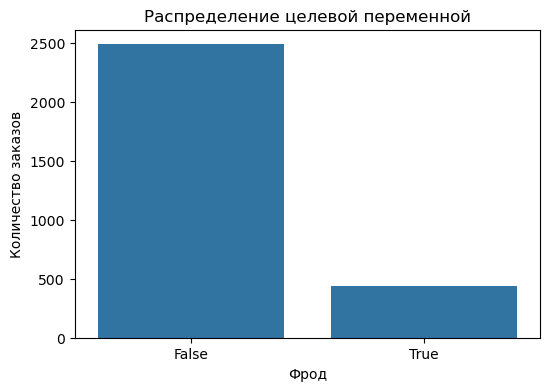

In [10]:
fig, ax = plt.subplots(1,1,figsize = (6,4))
sns.barplot(data[target_col[0]].value_counts())
ax.set_title("Распределение целевой переменной")
ax.set_xlabel("Фрод")
ax.set_ylabel("Количество заказов")
plt.show()

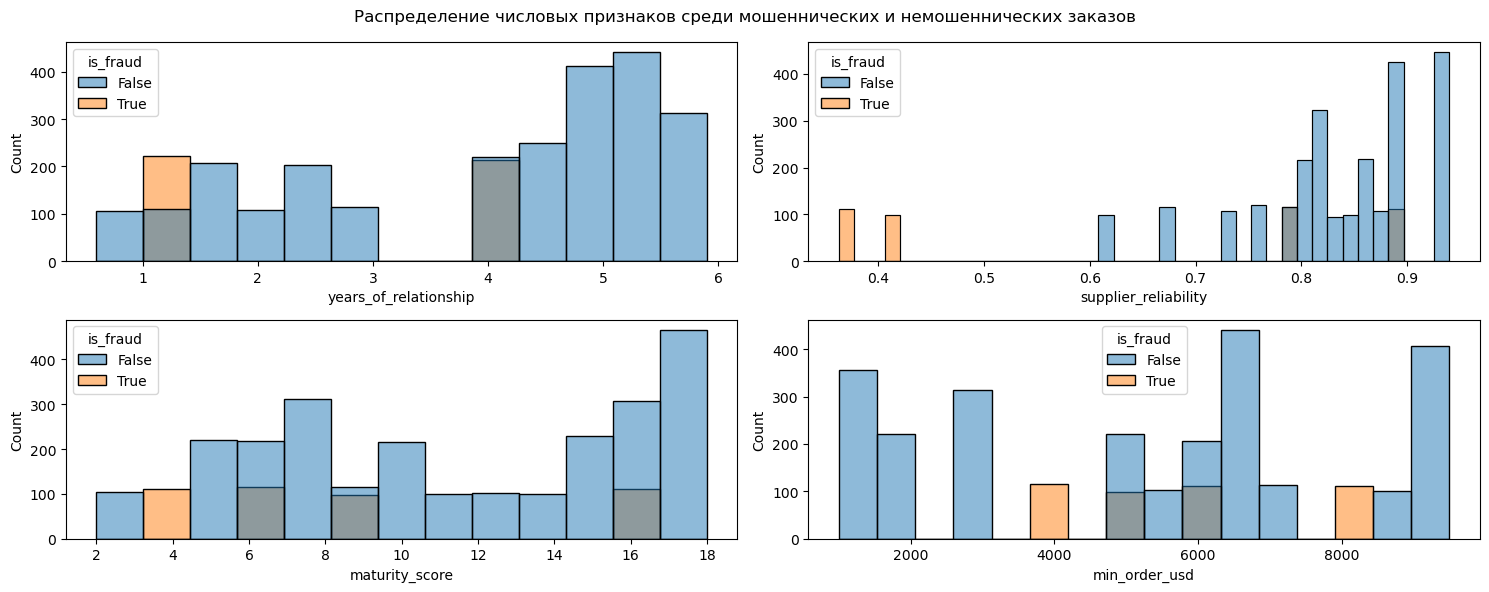

In [11]:
fig, axes = plt.subplots(2,2, figsize = (15,6))
for i, ax in enumerate(axes.flatten()):
    sns.histplot(x = num_cols[i], data = data, ax = ax, hue =target_col[0])
plt.suptitle("Распределение числовых признаков среди мошеннических и немошеннических заказов")
plt.tight_layout()
plt.show()

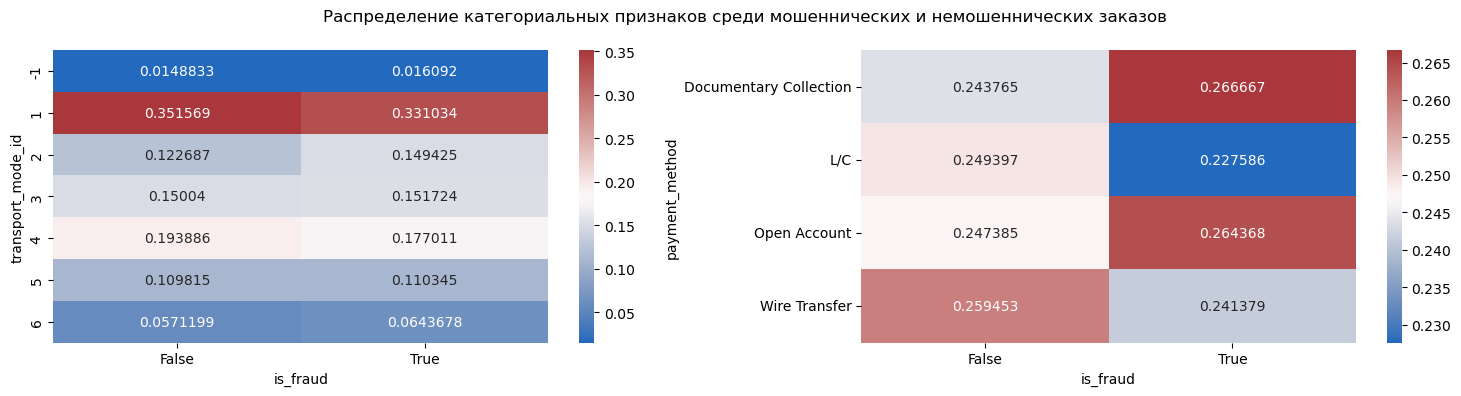

In [12]:
fig, axes = plt.subplots(1,2, figsize = (15,4))
for i, ax in enumerate(axes.flatten()):
    crosstab = pd.crosstab(data[cat_cols[i]], data[target_col[0]], normalize = "columns")
    sns.heatmap(crosstab, cmap = "vlag", annot = True, fmt = "g", ax = ax)
plt.suptitle("Распределение категориальных признаков среди мошеннических и немошеннических заказов")
plt.tight_layout()
plt.show()

# Логистическая регрессия

Accuracy: 0.9213675213675213
Precision: 1.0
Recall: 0.47126436781609193
F1: 0.640625


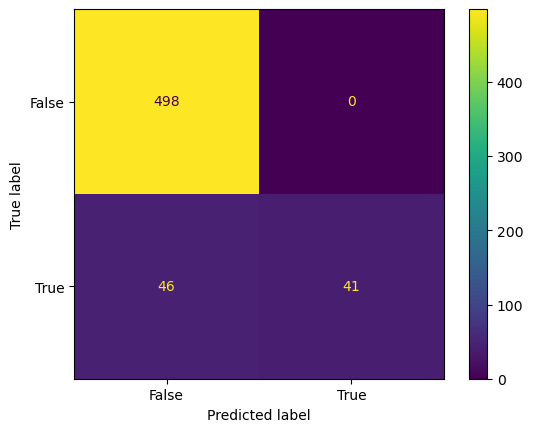

In [13]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

evaluate_model(y_pred, y_test)
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()


In [14]:
pd.DataFrame(model.named_steps["model"].coef_, columns = model.named_steps["preprocessor"].get_feature_names_out()).T

,0
num__years_of_relationship,-0.952810
num__supplier_reliability,-1.515461
num__maturity_score,-0.472672
num__min_order_usd,-0.809318
cat__transport_mode_id_-1,0.007833
cat__transport_mode_id_1,0.149097
cat__transport_mode_id_2,0.287504
cat__transport_mode_id_3,-0.152934
cat__transport_mode_id_4,-0.286904
cat__transport_mode_id_5,-0.143969


# KNN

Accuracy: 0.9623931623931624
Precision: 0.891566265060241
Recall: 0.8505747126436781
F1: 0.8705882352941177


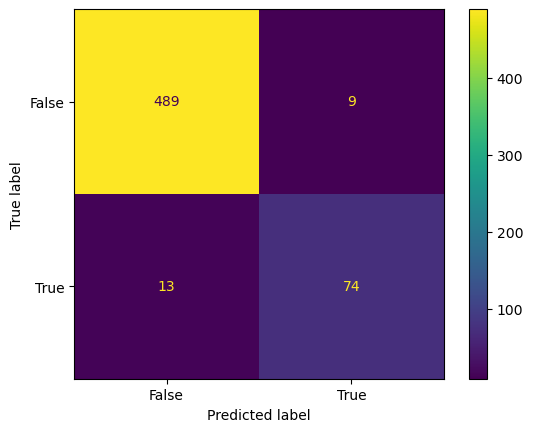

In [16]:
from sklearn.neighbors import KNeighborsClassifier

model= Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

evaluate_model(y_pred, y_test)
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()


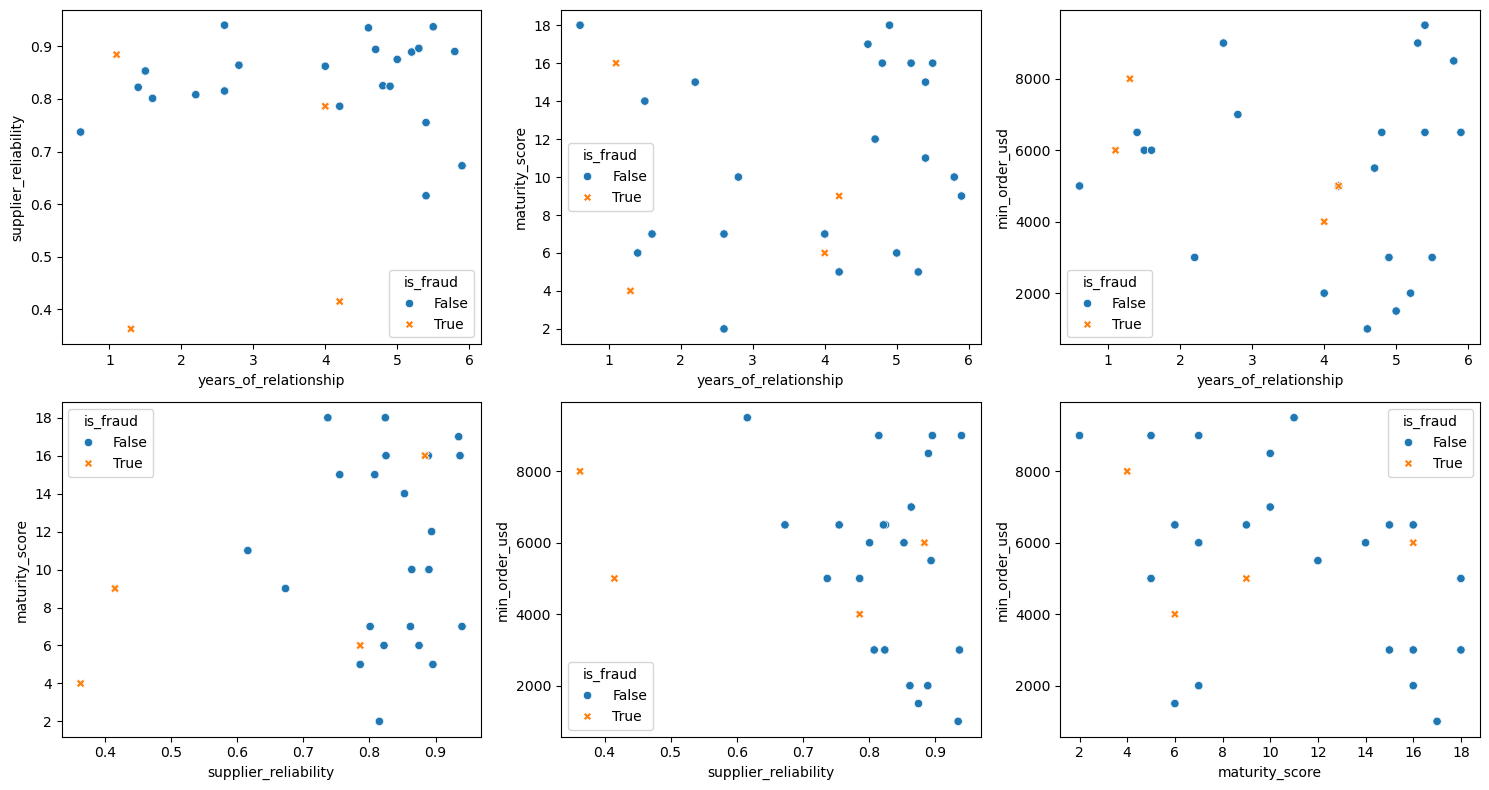

In [17]:
fig, ax = plt.subplots(2,3, figsize = (15,8))
sns.scatterplot(x = num_cols[0], y = num_cols[1], data = data, hue = target_col[0], ax = ax[0,0], style = target_col[0])
sns.scatterplot(x = num_cols[0], y = num_cols[2], data = data, hue = target_col[0], ax = ax[0,1], style = target_col[0])
sns.scatterplot(x = num_cols[0], y = num_cols[3], data = data, hue = target_col[0], ax = ax[0,2], style = target_col[0])
sns.scatterplot(x = num_cols[1], y = num_cols[2], data = data, hue = target_col[0], ax = ax[1,0], style = target_col[0])
sns.scatterplot(x = num_cols[1], y = num_cols[3], data = data, hue = target_col[0], ax = ax[1,1], style = target_col[0])
sns.scatterplot(x = num_cols[2], y = num_cols[3], data = data, hue = target_col[0], ax = ax[1,2], style = target_col[0])
plt.tight_layout()
plt.show()


# SVM

Accuracy: 0.9880341880341881
Precision: 1.0
Recall: 0.9195402298850575
F1: 0.9580838323353293


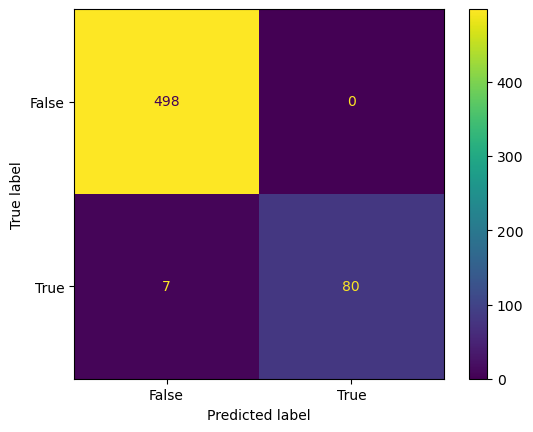

In [79]:
from sklearn.svm import SVC

model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(kernel='rbf', probability=True))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

evaluate_model(y_pred, y_test)
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()


In [80]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train[num_cols])
 
model = SVC(kernel="rbf", C=1.0, gamma="scale")
model.fit(X_scaled, y_train)

pairs = list(combinations(range(len(num_cols)), 2))  # 6 pairs for 4 features
n_cols = 3
n_rows = (len(pairs) + n_cols - 1) // n_cols              # ceil division → 2 rows
mesh_res = 200          # grid resolution; lower = faster, higher = smoother
fixed_vals = X_scaled.mean(axis=0)   # the "frozen" values for non-plotted features
 
classes = np.unique(y_train.values)
cmap_bg = plt.cm.RdYlBu           # background fill colormap
colors = plt.cm.Set1(np.linspace(0, 0.4, len(classes)))  # scatter point colors

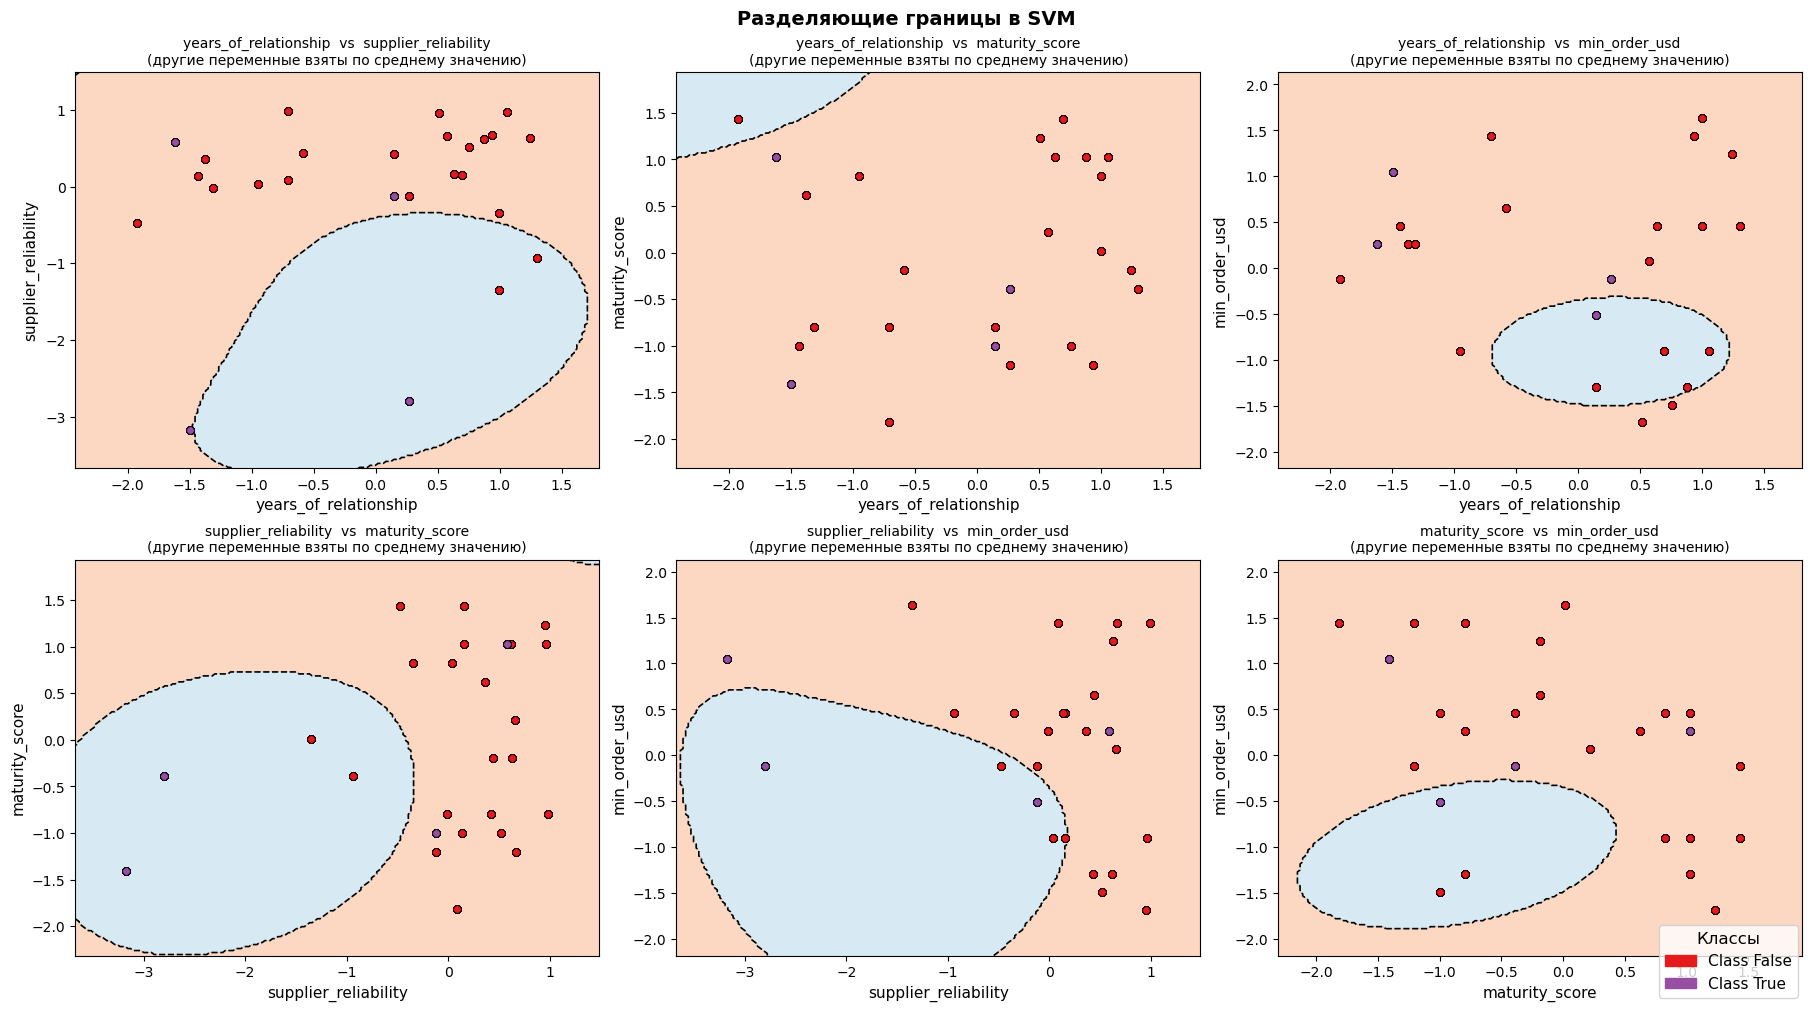

In [81]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), constrained_layout=True)
axes = axes.flatten()
 
for ax, (i, j) in zip(axes, pairs):
 
    x_min, x_max = X_scaled[:, i].min() - 0.5, X_scaled[:, i].max() + 0.5
    y_min, y_max = X_scaled[:, j].min() - 0.5, X_scaled[:, j].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, mesh_res),
                         np.linspace(y_min, y_max, mesh_res))
 
    # 4b. Assemble full input: vary features i & j, fix the rest at their mean
    grid_points = np.tile(fixed_vals, (xx.ravel().shape[0], 1))
    grid_points[:, i] = xx.ravel()
    grid_points[:, j] = yy.ravel()
 
    # 4c. Predict class labels across the grid
    Z = model.predict(grid_points).reshape(xx.shape)
 
    # 4d. Filled decision regions
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
 
    # 4e. Decision boundary line(s)
    ax.contour(xx, yy, Z, colors="black", linewidths=1.2, linestyles="--")
 
    # 4f. Scatter the actual data points
    for cls_idx, cls in enumerate(classes):
        mask = y_train.values == cls
        ax.scatter(X_scaled[mask.ravel(), i], X_scaled[mask.ravel(), j], color=colors[cls_idx], edgecolors="k", linewidths=0.5, s=30, label=f"Class {cls}", zorder=3)
 
    # 4g. Labels & title
    ax.set_xlabel(num_cols[i], fontsize=11)
    ax.set_ylabel(num_cols[j], fontsize=11)
    ax.set_title(f"{num_cols[i]}  vs  {num_cols[j]}\n" f"(другие переменные взяты по среднему значению)", fontsize=10)

for ax in axes[len(pairs):]:
    ax.set_visible(False)
 
# Build a single legend from the last active axis
handles = [mpatches.Patch(color=colors[k], label=f"Class {c}") for k, c in enumerate(classes)]
fig.legend(handles=handles, title="Классы",loc="lower right", fontsize=11, title_fontsize=12, bbox_to_anchor=(1.0, 0.0))
fig.suptitle("Разделяющие границы в SVM", fontsize=14, fontweight="bold")
 

plt.show()

# DecisionTree

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


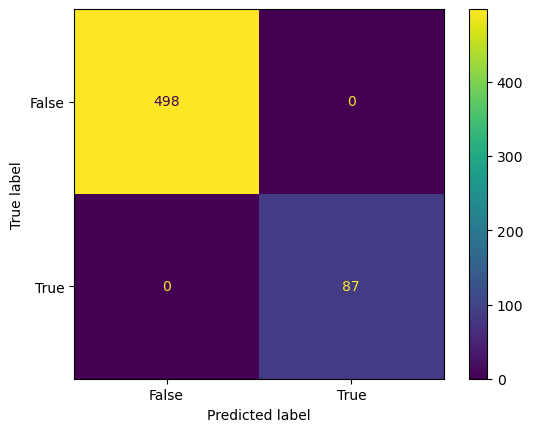

In [22]:
from sklearn.tree import DecisionTreeClassifier

model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=42))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

evaluate_model(y_pred, y_test)
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()


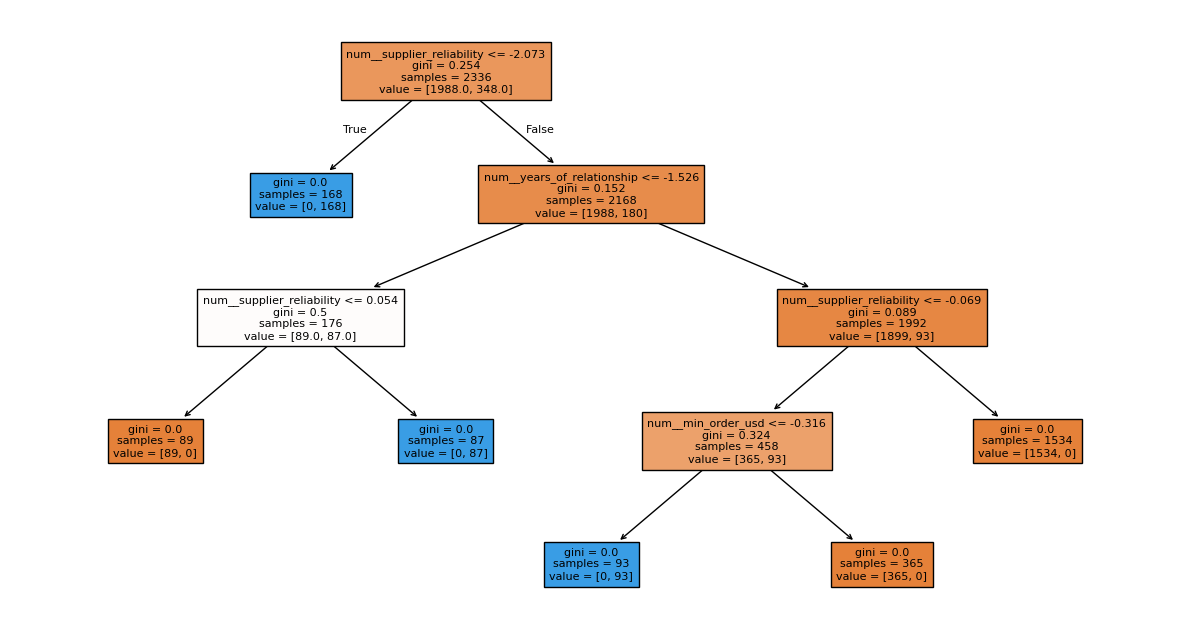

In [25]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
plot_tree(model.named_steps["model"], filled=True, fontsize = 8, feature_names= model.named_steps["preprocessor"].get_feature_names_out())
plt.show()

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


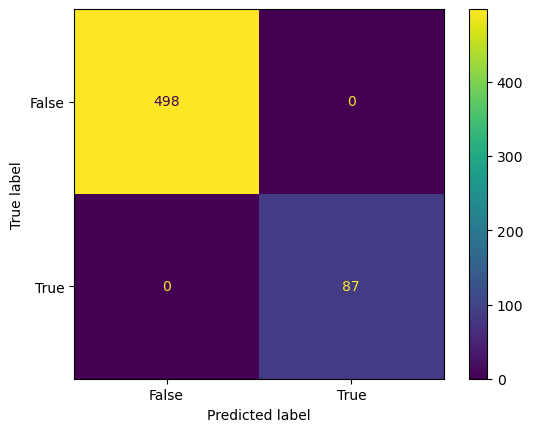

In [26]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train[num_cols], y_train)

y_pred = model.predict(X_test[num_cols])

evaluate_model(y_pred, y_test)
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()

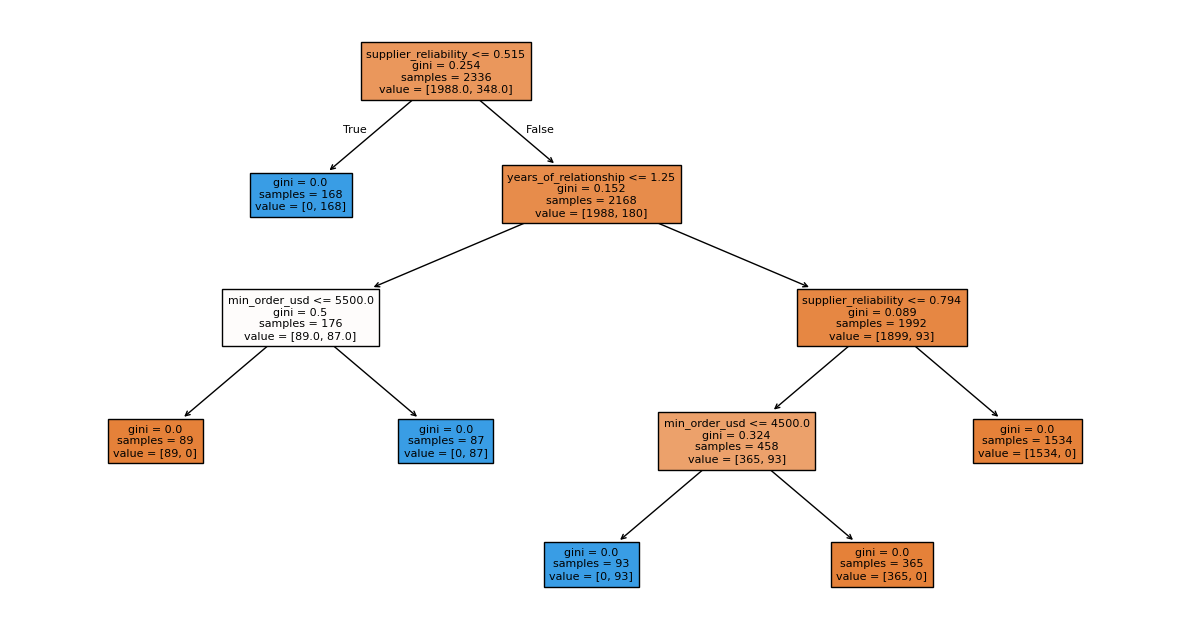

In [28]:
plt.figure(figsize=(15, 8))
plot_tree(model, filled=True, fontsize = 8, feature_names= model.feature_names_in_)
plt.show()